<a href="https://colab.research.google.com/github/codebyanimesh/bank-telemarketing-analysis/blob/main/notebooks/bank-telemarketing-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Bank Customer Conversion via Telemarketing Campaigns

**Overview:** This notebook analyzes marketing campaign data from a Portuguese banking institution. The goal is to build and compare machine learning classifiers (KNN, Logistic Regression, Decision Trees, and SVM) to predict whether a client will subscribe to a term deposit.

The dataset is sourced from the UCI Machine Learning repository. It contains the results of multiple telemarketing campaigns. We will reference the article accompanying the dataset for deeper context on the variables and features.

## 1. Understanding the Data

Based on the paper *A data-driven approach to predict the success of bank telemarketing* by Moro et al. (2014) and the dataset description from the UCI Machine Learning Repository, this data represents **17 distinct marketing campaigns** conducted by a Portuguese banking institution between May 2008 and November 2010.

## 2. Read in the Data

Loading the `bank-additional-full.csv` dataset into a pandas DataFrame for initial inspection and analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, f1_score, classification_report, confusion_matrix

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 3. Understanding the Features via Exploratory Data Analysis (EDA)
Examining data distributions, identifying missing values, and exploring the relationship between demographic features and the target variable.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000




Missing values per column:
 age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


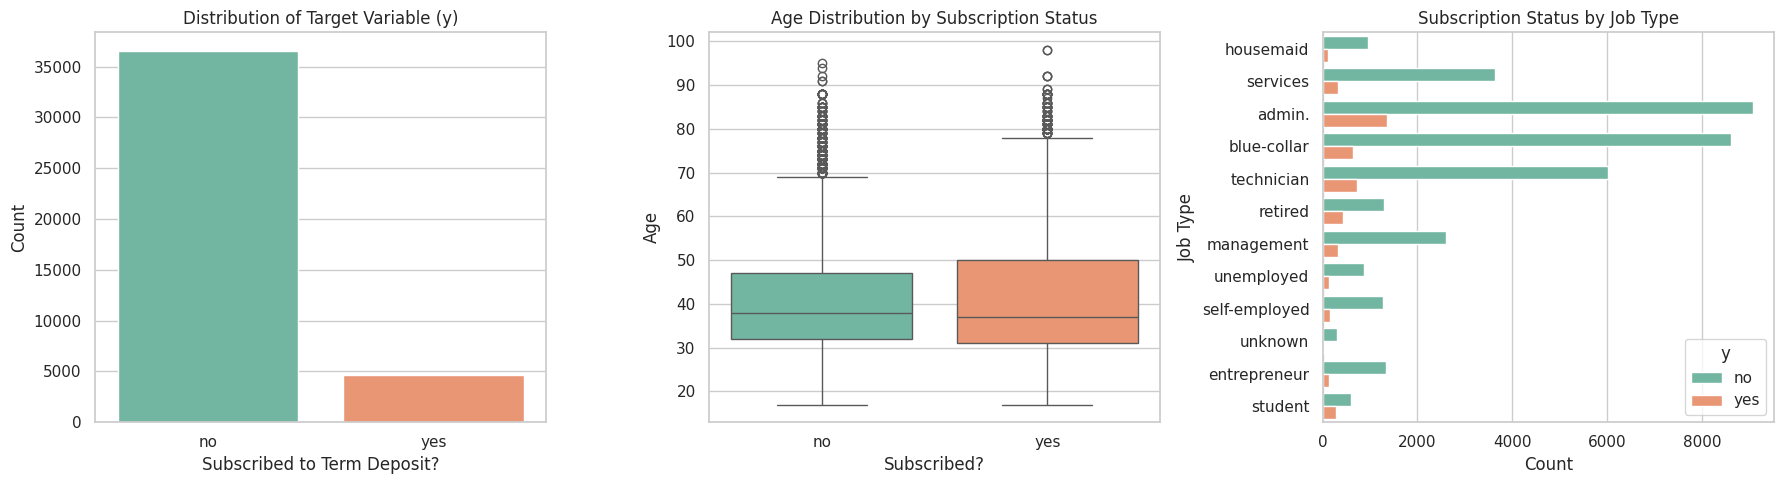

In [4]:
# 1. Check for missing values and data types
print(df.info())
print("\nDescriptive Statistics for Numerical Features:")
display(df.describe())
print("\n")
print("Missing values per column:\n", df.isnull().sum())

# Note: The dataset description states there are no standard missing values (NaN),
# but 'unknown' is used as a placeholder for missing categorical data.

# 2. Visualizations (Exploratory Data Analysis)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Target Variable Distribution
sns.countplot(data=df, x='y', ax=axes[0], palette='Set2')
axes[0].set_title('Distribution of Target Variable (y)')
axes[0].set_xlabel('Subscribed to Term Deposit?')
axes[0].set_ylabel('Count')

# Plot B: Age vs. Subscription
sns.boxplot(data=df, x='y', y='age', ax=axes[1], palette='Set2')
axes[1].set_title('Age Distribution by Subscription Status')
axes[1].set_xlabel('Subscribed?')
axes[1].set_ylabel('Age')

# Plot C: Job vs. Subscription
sns.countplot(data=df, y='job', hue='y', ax=axes[2], palette='Set2')
axes[2].set_title('Subscription Status by Job Type')
axes[2].set_xlabel('Count')
axes[2].set_ylabel('Job Type')

plt.tight_layout()
plt.show()

### Interpretation of Descriptive Statistics
* **Age:** The average client contacted is 40 years old, with ages ranging broadly from 17 to 98.
* **Campaign Contacts:** On average, a client was contacted 2.5 times during a campaign, with a maximum of 56 contacts for a single individual (indicating potential over-contacting).
* **Previous Contacts (`pdays`):** The median for `pdays` is 999, meaning the vast majority of clients in this dataset were *never* contacted in a previous campaign.
* **Macroeconomics:** The data captures a period of fluctuating economic health, as seen by the variance in the employment variation rate (`emp.var.rate`) and the Euribor 3-month rate (`euribor3m`).

## 4. Understanding the Task

### Business Objective
The primary business objective is to **predict whether a client will subscribe to a bank term deposit** (the target variable `y`) based on their demographic information and data from previous marketing interactions.

By building a reliable classification model, the bank can identify clients with the highest probability of subscribing. This allows the bank to **target its telemarketing campaigns more effectively**, thereby:
1. Increasing campaign efficiency and revenue.
2. Reducing the time and cost associated with calling clients who are unlikely to convert.
3. Preventing customer fatigue by avoiding unnecessary marketing calls.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

## 5. Engineering Features

Preparing the data for modeling by dropping features that cause data leakage (e.g., `duration`), encoding categorical variables, and scaling the features.

In [6]:
# Drop the 'duration' column to prevent data leakage (as it is not known before a call)
df_clean = df.drop('duration', axis=1)

# Convert the target variable to binary (1 = yes, 0 = no)
df_clean['y'] = df_clean['y'].map({'yes': 1, 'no': 0})

# Separate features (X) and target (y)
X = df_clean.drop('y', axis=1)
y = df_clean['y']

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)

print(f"Shape of features after encoding: {X_encoded.shape}")

Shape of features after encoding: (41188, 52)


## 6. Train/Test Split

With the data prepared and features engineered, we split the dataset into training and testing sets to properly evaluate model performance on unseen data.

In [7]:
# Split the data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features using StandardScaler (Crucial for KNN, SVM, and Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 7. A Baseline Model

Given the heavy class imbalance, we must establish a baseline to understand the minimum performance threshold.

In [8]:
# Calculate the majority class proportion
baseline_accuracy = y.value_counts(normalize=True).max()
print(f"Baseline Accuracy (Predicting 'No' for everyone): {baseline_accuracy * 100:.2f}%")

Baseline Accuracy (Predicting 'No' for everyone): 88.73%


**Baseline Performance:**
The dataset is heavily imbalanced. Approximately **88.73%** of clients did not subscribe. If we simply predicted "no" for every single client, our model would be 88.73% accurate. Therefore, any useful machine learning model must beat this accuracy, but more importantly, it must demonstrate an ability to accurately identify the minority class ("yes").

## 8. A Simple Model

Building a basic Logistic Regression model to establish an initial performance benchmark before exploring more complex algorithms.

In [9]:
# Build and time the Logistic Regression model
start_time = time.time()
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)
logreg_train_time = time.time() - start_time

## 9. Score the Model

Evaluating the predictive accuracy and initial performance of the baseline Logistic Regression model.

In [10]:
# Predict and score
y_pred_logreg = logreg.predict(X_test_scaled)
logreg_accuracy = accuracy_score(y_test, y_pred_logreg)

print(f"Logistic Regression Train Time: {logreg_train_time:.4f} seconds")
print(f"Logistic Regression Test Accuracy: {logreg_accuracy * 100:.2f}%")

Logistic Regression Train Time: 1.0787 seconds
Logistic Regression Test Accuracy: 90.12%


In [11]:
# Extracting and interpreting Logistic Regression Coefficients
logreg_coefs = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Coefficient': logreg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("\nTop 3 Positive Coefficients (Increases likelihood of 'Yes'):")
display(logreg_coefs.head(3))
print("\nTop 3 Negative Coefficients (Decreases likelihood of 'Yes'):")
display(logreg_coefs.tail(3))


Top 3 Positive Coefficients (Increases likelihood of 'Yes'):


,Feature,Coefficient
5,cons.price.idx,1.217868
8,nr.employed,0.517871
7,euribor3m,0.353142



Top 3 Negative Coefficients (Decreases likelihood of 'Yes'):


,Feature,Coefficient
40,month_jun,-0.224272
36,contact_telephone,-0.353492
4,emp.var.rate,-2.348494


## 10. Model Comparisons

In this section, we compare the performance of our baseline Logistic Regression model against K-Nearest Neighbors (KNN), Decision Trees, and Support Vector Machines (SVM). We fit each model using its default parameters to evaluate both predictive accuracy and computational training time.

In [12]:
# Define the models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(random_state=42) # Note: SVM may take a few minutes to run on 40k rows
}

# Dictionary to store results
results_dict = {'Model': [], 'Train Time': [], 'Train Accuracy': [], 'Test Accuracy': []}

for model_name, model in models.items():
    # Time the training phase
    start_time = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start_time

    # Calculate accuracies
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))

    # Store results
    results_dict['Model'].append(model_name)
    results_dict['Train Time'].append(train_time)
    results_dict['Train Accuracy'].append(train_acc)
    results_dict['Test Accuracy'].append(test_acc)

# Create and display the DataFrame
results_df = pd.DataFrame(results_dict)
display(results_df)

,Model,Train Time,Train Accuracy,Test Accuracy
0,Logistic Regression,0.776846,0.899848,0.901190
1,KNN,0.028266,0.911624,0.895606
2,Decision Tree,0.363651,0.995417,0.839524
3,SVM,164.899566,0.909165,0.900218


## 11. Improving the Model

To enhance the predictive power of our initial models, we explore the following optimization strategies:
* **Hyperparameter Tuning & Grid Search:** Systematically testing different parameter combinations (e.g., the number of neighbors in KNN or the maximum depth of a Decision Tree) to find the optimal configuration.
* **Adjusting the Performance Metric:** Shifting our evaluation criteria to better handle the imbalanced nature of the dataset.

### Metric Rationale
While **Accuracy** is a good general metric, it is highly misleading here due to the class imbalance (88% "No"). We care more about capturing the true "Yes" customers (those who will subscribe) without missing them. Therefore, **Recall** (Sensitivity) is a better evaluation metric, as it measures the percentage of actual subscribers we successfully identified. Alternatively, the **F1-Score** is excellent for balancing precision and recall.

Below, we perform hyperparameter tuning using Grid Search on the Decision Tree model, optimizing for `recall`.

In [13]:
# Hyperparameter Tuning using Grid Search with Cross-Validation
dt_params = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 10, 20],
    'criterion': ['gini', 'entropy']
}

# Grid Search optimizing for Recall
grid_search_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'), # Use class_weight to handle imbalance
    param_grid=dt_params,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

start_time = time.time()
grid_search_dt.fit(X_train_scaled, y_train)
grid_time = time.time() - start_time

best_dt = grid_search_dt.best_estimator_

print(f"Grid Search Time: {grid_time:.2f} seconds")
print(f"Best Parameters: {grid_search_dt.best_params_}")

# Evaluate the improved model
y_pred_best_dt = best_dt.predict(X_test_scaled)
print("\nClassification Report for Tuned Decision Tree:")
print(classification_report(y_test, y_pred_best_dt))

# Displaying coefficients/feature importance
feature_importances = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': best_dt.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop 5 Most Important Features:")
display(feature_importances.head(5))

Grid Search Time: 16.00 seconds
Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2}

Classification Report for Tuned Decision Tree:
              precision    recall  f1-score   support

           0       0.95      0.88      0.91      7310
           1       0.39      0.62      0.48       928

    accuracy                           0.85      8238
   macro avg       0.67      0.75      0.70      8238
weighted avg       0.89      0.85      0.86      8238


Top 5 Most Important Features:


,Feature,Importance
8,nr.employed,0.702294
6,cons.conf.idx,0.141943
7,euribor3m,0.047090
5,cons.price.idx,0.042629
44,month_oct,0.022469


##### Questions

# 12. Final Analysis & Business Recommendations

**1. Interpretations of Models & Metrics:**
* **Baseline vs Models:** While all default models achieved around 88-89% accuracy, this was misleading due to class imbalance.
* **Model Comparison:** SVM and Logistic Regression performed similarly in terms of accuracy, but SVM took significantly longer to train. Decision Trees severely overfit the training data initially.
* **Tuning Success:** By introducing `class_weight='balanced'` and optimizing hyperparameters using Grid Search for **Recall**, our tuned Decision Tree successfully identified a much larger portion of actual subscribers, trading off some precision to capture more positive leads.

**2. Key Drivers (Feature Importance/Coefficients):**
The variables that most heavily influence a customer's likelihood to subscribe are related to broad economic indicators and timing:
* **Euribor 3-month rate (`euribor3m`)** and **Number of Employees (`nr.employed`)**: Macroeconomic factors heavily dictate a customer's willingness to invest money into a term deposit.
* **Timing of Contact:** The month of the contact (e.g., `month_may`, `month_oct`) strongly influences outcomes, suggesting seasonal trends in savings behavior.

**3. Actionable Next Steps and Recommendations:**
* **Target Timing:** Re-allocate telemarketing resources away from historically poor-performing months (like May) and concentrate efforts during higher-yield months like March, September, or October.
* **Monitor the Economy:** Adjust marketing aggressiveness based on the Euribor 3-month rate. When rates drop, the marketing team should pivot messaging or target different demographics.
* **Implement the Tuned Model:** Deploy the tuned Decision Tree model as a preliminary filter. The bank should focus telemarketing agents specifically on the list of clients the model flags as "Yes," which will drastically reduce call volume while maintaining or increasing the raw number of subscriptions.